# Book Recommender

## Imports

In [14]:
import pandas as pd
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
import networkx as nx
from collections import defaultdict
import warnings
import os
import matplotlib.pyplot as plt
import seaborn as sns
# warnings.filterwarnings('ignore')

## Data Loading

In [2]:
os.getcwd()

'C:\\Users\\HP\\Documents\\Projects\\recommender-systems-project'

In [3]:
books_raw = pd.read_csv('data/Books.csv', encoding='utf-8', on_bad_lines='error')
ratings_raw = pd.read_csv('data/Ratings.csv', encoding='latin-1', on_bad_lines='error')
users_raw = pd.read_csv('data/Users.csv', encoding='latin-1', on_bad_lines='error')

C:\Users\HP\AppData\Local\Temp\ipykernel_23604\3708056424.py:1: DtypeWarning: Columns (3) have mixed types. Specify dtype option on import or set low_memory=False.
  books_raw = pd.read_csv('data/Books.csv', encoding='utf-8', on_bad_lines='error')


### Checking the year-of-publication issue

#### Look for data types

In [4]:
type_counts = books_raw['Year-Of-Publication'].apply(type).value_counts()
print(type_counts)

Year-Of-Publication
<class 'int'>    205824
<class 'str'>     65536
Name: count, dtype: int64


#### Str types

In [5]:
strings_only = books_raw[books_raw['Year-Of-Publication'].apply(lambda x: isinstance(x, str))]
print(strings_only['Year-Of-Publication'].head())

196608    2000
196609    1995
196610    1999
196611    2004
196612    2003
Name: Year-Of-Publication, dtype: object


#### Look for non-numeric values

In [6]:
non_numeric = books_raw[books_raw['Year-Of-Publication'].apply(lambda x: isinstance(x, str) and not x.isdigit())]
print(non_numeric['Year-Of-Publication'].unique())

['DK Publishing Inc' 'Gallimard']


#### How many non-numeric values are there?

In [7]:
mismatched_counts = books_raw[books_raw['Year-Of-Publication'].isin(['DK Publishing Inc', 'Gallimard'])]['Year-Of-Publication'].value_counts()
print(mismatched_counts)

Year-Of-Publication
DK Publishing Inc    2
Gallimard            1
Name: count, dtype: int64


#### Check these non-numeric records

In [8]:
problematic_rows = books_raw[books_raw['Year-Of-Publication'].isin(['DK Publishing Inc', 'Gallimard'])]
problematic_rows

,ISBN,Book-Title,Book-Author,Year-Of-Publication,Publisher,Image-URL-S,Image-URL-M,Image-URL-L
209538,078946697X,"DK Readers: Creating the X-Men, How It All Beg...",2000,DK Publishing Inc,http://images.amazon.com/images/P/078946697X.0...,http://images.amazon.com/images/P/078946697X.0...,http://images.amazon.com/images/P/078946697X.0...,NaN
220731,2070426769,"Peuple du ciel, suivi de 'Les Bergers\"";Jean-M...",2003,Gallimard,http://images.amazon.com/images/P/2070426769.0...,http://images.amazon.com/images/P/2070426769.0...,http://images.amazon.com/images/P/2070426769.0...,NaN
221678,0789466953,"DK Readers: Creating the X-Men, How Comic Book...",2000,DK Publishing Inc,http://images.amazon.com/images/P/0789466953.0...,http://images.amazon.com/images/P/0789466953.0...,http://images.amazon.com/images/P/0789466953.0...,NaN


#### Fix the problematic records

In [9]:
# Fix the first 'DK Publishing Inc' record (index 209538)
books_raw.loc[209538, 'Book-Title'] = "DK Readers: Creating the X-Men, How It All Began (Level 4: Proficient Readers)"
books_raw.loc[209538, 'Book-Author'] = "Michael Teitelbaum"
books_raw.loc[209538, 'Year-Of-Publication'] = 2000
books_raw.loc[209538, 'Publisher'] = "DK Publishing Inc"

# Fix the 'Gallimard' record (index 220731)
books_raw.loc[220731, 'Book-Title'] = "Peuple du ciel, suivi de 'Les Bergers'"
books_raw.loc[220731, 'Book-Author'] = "Jean-Marie Gustave Le Clézio"
books_raw.loc[220731, 'Year-Of-Publication'] = 2003
books_raw.loc[220731, 'Publisher'] = "Gallimard"

# Fix the second 'DK Publishing Inc' record (index 221678)
books_raw.loc[221678, 'Book-Title'] = "DK Readers: Creating the X-Men, How Comic Books Come to Life (Level 4: Proficient Readers)"
books_raw.loc[221678, 'Book-Author'] = "James Buckley"
books_raw.loc[221678, 'Year-Of-Publication'] = 2000
books_raw.loc[221678, 'Publisher'] = "DK Publishing Inc"

#### Parse the year-of-publication column to numeric

In [10]:
books_raw['Year-Of-Publication'] = pd.to_numeric(books_raw['Year-Of-Publication'], errors='raise')
print(books_raw['Year-Of-Publication'].dtype)

int64


## Data Analysis

In [11]:
print("BOOKS DATAFRAME INFO:")
print(books_raw.info())

print("\nRATINGS DATAFRAME INFO:")
print(ratings_raw.info())

print("\nUSERS DATAFRAME INFO:")
print(users_raw.info())

BOOKS DATAFRAME INFO:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 271360 entries, 0 to 271359
Data columns (total 8 columns):
 #   Column               Non-Null Count   Dtype 
---  ------               --------------   ----- 
 0   ISBN                 271360 non-null  object
 1   Book-Title           271360 non-null  object
 2   Book-Author          271358 non-null  object
 3   Year-Of-Publication  271360 non-null  int64 
 4   Publisher            271358 non-null  object
 5   Image-URL-S          271360 non-null  object
 6   Image-URL-M          271360 non-null  object
 7   Image-URL-L          271357 non-null  object
dtypes: int64(1), object(7)
memory usage: 16.6+ MB
None

RATINGS DATAFRAME INFO:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1149780 entries, 0 to 1149779
Data columns (total 3 columns):
 #   Column       Non-Null Count    Dtype 
---  ------       --------------    ----- 
 0   User-ID      1149780 non-null  int64 
 1   ISBN         1149780 non-null  object
 2 

### Books

In [12]:
books_raw.describe()

,Year-Of-Publication
count,271360.000000
mean,1959.761273
std,257.992836
min,0.000000
25%,1989.000000
50%,1995.000000
75%,2000.000000
max,2050.000000


#### Outliers

In [22]:
print(f"0: {(books_raw['Year-Of-Publication'] == 0).sum()}")
print(f"Before 1900 (non-zero): {((books_raw['Year-Of-Publication'] < 1900) & (books_raw['Year-Of-Publication'] > 0)).sum()}")
print(f"After 2004: {(books_raw['Year-Of-Publication'] > 2004).sum()}")
print(f"After 2025: {(books_raw['Year-Of-Publication'] > 2025).sum()}")

0: 4618
Before 1900 (non-zero): 4
After 2004: 72
After 2025: 12


> NOTE: dataset is made in 2004, so any book published after 2004 is an error.

#### Books before 1900 but non-zero

In [23]:
books_raw[(books_raw['Year-Of-Publication'] < 1900) & (books_raw['Year-Of-Publication'] > 0)][['Book-Title', 'Book-Author', 'Year-Of-Publication']]

,Book-Title,Book-Author,Year-Of-Publication
171817,"Complete Works 10 Volumes [2,6,7,8,9] (Notable...",Benjamin Franklin,1806
227531,Dalan-i bihisht (Dastan-i Irani),Nazi Safavi,1378
245607,"Hugh Wynne, Free Quaker (2 Volumes (BCL1-PS Am...",Silas Weir Mitchell,1897
253750,Tasht-i khun,IsmaÂ°il Fasih,1376


> 171817, 245607 seems to be correct; other two are errors

#### Filtering out the outliers

In [35]:
books_clean = books_raw[(books_raw['Year-Of-Publication'] > 1800) & 
                           (books_raw['Year-Of-Publication'] <= 2004)].copy()
books_outliers_isbns = books_raw[~books_raw.index.isin(books_clean.index)]['ISBN'].tolist()
print(f"{len(books_raw) - len(books_clean)} outliers removed. Remaining books: {len(books_clean)}")
print(f"Outlier ISBNs length: {len(books_outliers_isbns)}")
print(f"Sample outlier ISBNs: {books_outliers_isbns[:5]}")

4692 outliers removed. Remaining books: 266668
Outlier ISBNs length: 4692
Sample outlier ISBNs: ['3150000335', '342311360X', '0571197639', '3596214629', '8845229041']


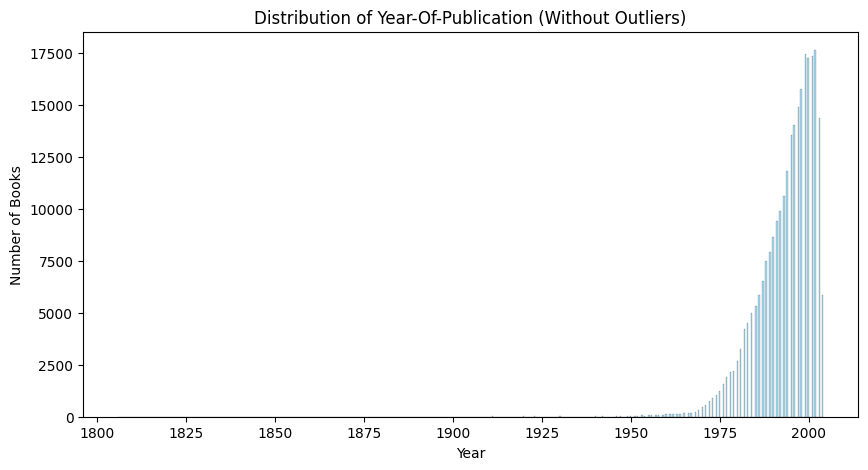

In [36]:
plt.figure(figsize=(10, 5))
sns.histplot(books_clean['Year-Of-Publication'], bins=500, kde=False, color='skyblue') # type: ignore
plt.title('Distribution of Year-Of-Publication (Without Outliers)')
plt.xlabel('Year')
plt.ylabel('Number of Books')
plt.show()

### Users

#### Check age

In [42]:
users_raw.describe()

,User-ID,Age
count,278858.00000,168096.000000
mean,139429.50000,34.751434
std,80499.51502,14.428097
min,1.00000,0.000000
25%,69715.25000,24.000000
50%,139429.50000,32.000000
75%,209143.75000,44.000000
max,278858.00000,244.000000


#### Handle outliers

In [46]:
users_clean = users_raw[(users_raw['Age'] > 0) & (users_raw['Age'] < 120)].copy()
print(f"Original users: {len(users_raw):,}")
print(f"Cleaned users (valid ages): {len(users_clean):,}")
print(f"Removed {len(users_raw) - len(users_clean):,} users with invalid ages.")

Original users: 278,858
Cleaned users (valid ages): 167,602
Removed 111,256 users with invalid ages.


#### Hist age

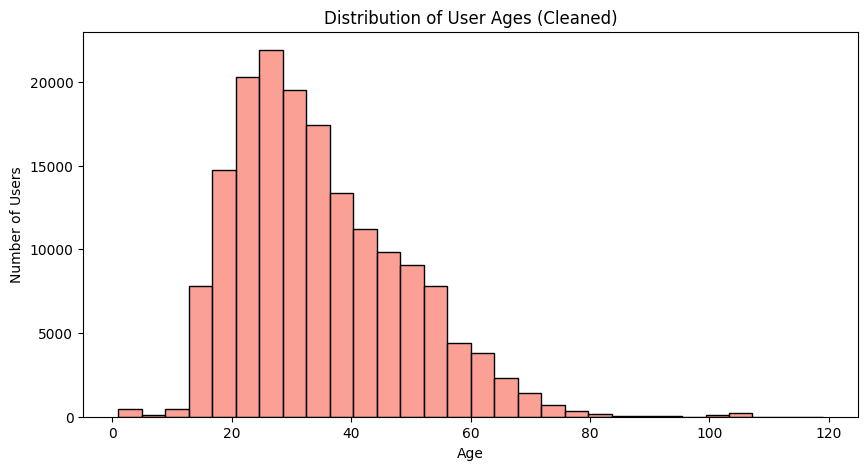

In [50]:
plt.figure(figsize=(10, 5))
sns.histplot(users_clean['Age'], bins=30, kde=False, color='salmon') # type: ignore
plt.title('Distribution of User Ages (Cleaned)')
plt.xlabel('Age')
plt.ylabel('Number of Users')
plt.show()

#### Extract country from location

In [ ]:
users_clean['Country'] = users_clean['Location'].apply(
    lambda x: x.split(',')[-1].strip().lower() if pd.notna(x) else 'unknown'
)
print(f"Country counts: {users_clean['Country'].value_counts().head(10)}")

Country counts: Country
usa               76322
spain             12552
united kingdom    12490
canada            11354
germany           10600
australia          8857
italy              5359
france             3000
portugal           2658
new zealand        2000
Name: count, dtype: int64


### Ratings

In [28]:
ratings_raw.describe()

,User-ID,Book-Rating
count,1.149780e+06,1.149780e+06
mean,1.403864e+05,2.866950e+00
std,8.056228e+04,3.854184e+00
min,2.000000e+00,0.000000e+00
25%,7.034500e+04,0.000000e+00
50%,1.410100e+05,0.000000e+00
75%,2.110280e+05,7.000000e+00
max,2.788540e+05,1.000000e+01


> As per dataset description in kaggle, ratings 1-10 says the user has rated, while 0 means the user has not rated the book. So we will filter out the records with rating 0.

#### Check for interactions with outlier books

In [40]:
ratings_clean_all_interactions = ratings_raw[ratings_raw['ISBN'].isin(books_clean['ISBN'])].copy()

print(f"Original ratings: {len(ratings_raw):,}")
print(f"Cleaned ratings: {len(ratings_clean_all_interactions):,}")
print(f"Removed {len(ratings_raw) - len(ratings_clean_all_interactions):,} outlier interactions.")

Original ratings: 1,149,780
Cleaned ratings: 1,016,920
Removed 132,860 outlier interactions.


#### Select only rated interactions

In [48]:
ratings_clean_with_invalid_users = ratings_clean_all_interactions[ratings_clean_all_interactions['Book-Rating'] > 0].copy()
print(f"Original ratings: {len(ratings_clean_all_interactions):,}")
print(f"Cleaned ratings (only rated interactions): {len(ratings_clean_with_invalid_users):,}")
print(f"Removed {len(ratings_clean_all_interactions) - len(ratings_clean_with_invalid_users):,} unrated interactions.")

Original ratings: 1,016,920
Cleaned ratings (only rated interactions): 377,972
Removed 638,948 unrated interactions.


> NOTE: extremely difficult to say how the interaction of a person with a book without rating. It can be positive, negative, or neutral. So we will filter out the records with rating 0, which means the user has not rated the book. A good judgement cannot be made without being biased.

#### Select ratings with valid users

In [49]:
ratings_clean = ratings_clean_with_invalid_users[ratings_clean_with_invalid_users['User-ID'].isin(users_clean['User-ID'])].copy()
print(f"Original ratings: {len(ratings_clean_with_invalid_users):,}")
print(f"Cleaned ratings (only valid users): {len(ratings_clean):,}")
print(f"Removed {len(ratings_clean_with_invalid_users) - len(ratings_clean):,} ratings from invalid users.")

Original ratings: 377,972
Cleaned ratings (only valid users): 264,919
Removed 113,053 ratings from invalid users.


#### Hist of ratings

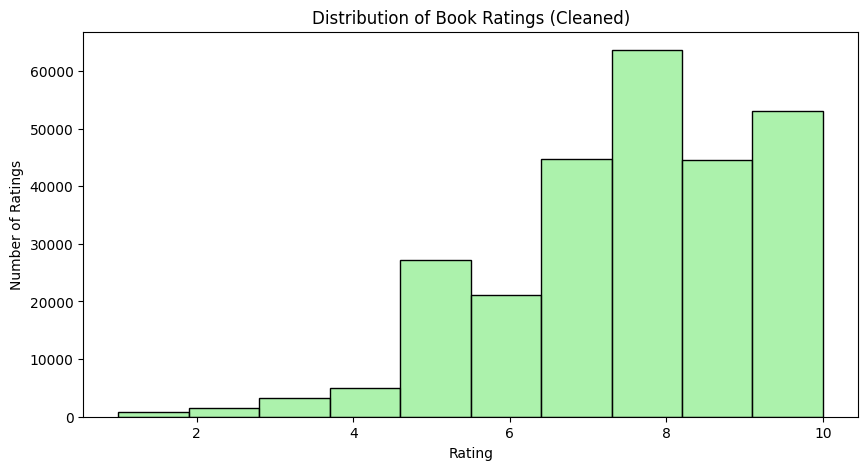

In [ ]:
plt.figure(figsize=(10, 5))
sns.histplot(ratings_clean['Book-Rating'], bins=10, kde=False, color='lightgreen') # type: ignore
plt.title('Distribution of Book Ratings (Cleaned)')
plt.xlabel('Rating')
plt.ylabel('Number of Ratings')
plt.show()

#### Users with no ratings

In [ ]:
users_with_ratings = ratings_clean['User-ID'].unique()
users_no_ratings = users_clean[~users_clean['User-ID'].isin(users_with_ratings)]
print(f"Users with ratings: {len(users_with_ratings):,}")
print(f"Users with no ratings: {len(users_no_ratings):,}")
print(f"Total users: {len(users_clean):,}")

Users with ratings: 39,785
Users with no ratings: 127,817
Total users: 167,602


#### Books with no ratings

In [57]:
books_with_ratings = ratings_clean['ISBN'].unique()
books_no_ratings = books_clean[~books_clean['ISBN'].isin(books_with_ratings)]
print(f"Books with ratings: {len(books_with_ratings):,}")
print(f"Books with no ratings: {len(books_no_ratings):,}")
print(f"Total books: {len(books_clean):,}")

Books with ratings: 117,600
Books with no ratings: 149,068
Total books: 266,668


> No rating ones are cold-start

## Data Split

In [59]:
# --- DOWN-SAMPLING FOR MEMORY EFFICIENCY ---
top_users = ratings_clean['User-ID'].value_counts().head(1000).index
top_books = ratings_clean['ISBN'].value_counts().head(2000).index

sampled_ratings = ratings_clean[
    ratings_clean['User-ID'].isin(top_users) &
    ratings_clean['ISBN'].isin(top_books)
].copy()

# Sync books and users dataframes with the final sampled ratings
final_isbns = set(sampled_ratings['ISBN'])
final_users = set(sampled_ratings['User-ID'])

books_sampled = books_clean[books_clean['ISBN'].isin(final_isbns)].reset_index(drop=True)
users_sampled = users_clean[users_clean['User-ID'].isin(final_users)].reset_index(drop=True)

# --- OPTIMIZED USER-BASED TRAIN/TEST SPLIT ---
train_data = []
test_data = []

for user_id, group in sampled_ratings.groupby('User-ID'):
    if len(group) <= 1:
        # If the user only has 1 rating, it must go to training
        train_data.append(group)
    else:
        # Otherwise, split 80/20 for this specific user
        u_train, u_test = train_test_split(group, test_size=0.2, random_state=42)
        train_data.append(u_train)
        test_data.append(u_test)

train_ratings = pd.concat(train_data, ignore_index=True)
test_ratings = pd.concat(test_data, ignore_index=True)

print(f"Sampled Dataset -> Users: {len(users_sampled)}, Books: {len(books_sampled)}")
print(f"Training on {len(train_ratings)} interactions.")
print(f"Testing on {len(test_ratings)} interactions.")

Sampled Dataset -> Users: 975, Books: 1991
Training on 17368 interactions.
Testing on 4815 interactions.


## Feature Engineering

In [ ]:
print("Building Content-Based Features (TF-IDF)...")
# Combine text features for TF-IDF
books_sampled['content'] = (
    books_sampled['Book-Title'].fillna('') + ' ' +
    books_sampled['Book-Author'].fillna('') + ' ' +
    books_sampled['Year-Of-Publication'].astype(str)
)

tfidf_vectorizer = TfidfVectorizer(max_features=500, stop_words='english', ngram_range=(1, 2))
item_profiles = tfidf_vectorizer.fit_transform(books_sampled['content'])


print("Building Collaborative Filtering Features (User-Item Matrix)...")
user_item_matrix = train_ratings.pivot_table(
    index='User-ID', columns='ISBN', values='Book-Rating', fill_value=0
)
# Compute Cosine Similarity between users
user_similarity_matrix = pd.DataFrame(
    cosine_similarity(user_item_matrix),
    index=user_item_matrix.index,
    columns=user_item_matrix.index
)


print("Building Network Features (PageRank for Popularity/Graph Analysis)...")
bipartite_graph = nx.Graph()

# Add nodes and edges
for user_id in train_ratings['User-ID'].unique():
    bipartite_graph.add_node(f"U{user_id}", node_type='user')
for isbn in books_sampled['ISBN'].unique():
    bipartite_graph.add_node(f"I{isbn}", node_type='item')
for _, row in train_ratings.iterrows():
    if f"U{row['User-ID']}" in bipartite_graph.nodes() and f"I{row['ISBN']}" in bipartite_graph.nodes():
        bipartite_graph.add_edge(f"U{row['User-ID']}", f"I{row['ISBN']}", weight=row['Book-Rating'])

# Calculate global popularity via PageRank
pagerank_scores = nx.pagerank(bipartite_graph, weight='weight', max_iter=50)
item_popularity = {k.replace('I', ''): v for k, v in pagerank_scores.items() if k.startswith('I')}

print("✓ All features built successfully.")

Building Content-Based Features (TF-IDF)...
Building Collaborative Filtering Features (User-Item Matrix)...
Building Network Features (PageRank for Popularity/Graph Analysis)...
✓ All features built successfully.


### Recommendation Logic

In [61]:
# ==============================================================================
# STEP 3.2: RECOMMENDATION FUNCTIONS
# ==============================================================================

COLD_START_THRESHOLD = 3

def get_collaborative_scores(user_id, exclude_isbns):
    """User-based CF: Finds similar users and weights their ratings."""
    if user_id not in user_similarity_matrix.index:
        return {}
    
    # Top 5 similar users (excluding the user themselves)
    similar_users = user_similarity_matrix[user_id].sort_values(ascending=False)[1:6]
    scores = defaultdict(float)
    
    for sim_user, similarity in similar_users.items():
        if similarity <= 0 or sim_user not in user_item_matrix.index:
            continue
            
        sim_user_ratings = user_item_matrix.loc[sim_user]
        for isbn, rating in sim_user_ratings.items():
            if rating > 0 and isbn not in exclude_isbns:
                scores[isbn] += similarity * rating
                
    if scores:
        max_score = max(scores.values())
        scores = {k: v/max_score for k, v in scores.items()} # Normalize
    return scores

def get_content_scores(user_id, exclude_isbns):
    """Content-based: Recommends books similar to those the user rated highly."""
    user_ratings = train_ratings[train_ratings['User-ID'] == user_id]
    liked_isbns = user_ratings[user_ratings['Book-Rating'] >= 7]['ISBN'].values
    
    if len(liked_isbns) == 0:
        return {}
        
    liked_indices = books_sampled.index[books_sampled['ISBN'].isin(liked_isbns)].tolist()
    if not liked_indices:
        return {}
        
    # Create an average profile of what the user likes
    user_profile = np.asarray(item_profiles[liked_indices].mean(axis=0))
    similarities = cosine_similarity(user_profile, item_profiles)[0]
    
    scores = {}
    for idx, isbn in enumerate(books_sampled['ISBN']):
        if isbn not in exclude_isbns:
            scores[isbn] = similarities[idx]
    return scores

def apply_demographic_personalization(user_id, scores):
    """Bonus: Boosts scores based on user Age and Book Publication Year."""
    if user_id not in users_sampled['User-ID'].values:
        return scores
        
    age = users_sampled.loc[users_sampled['User-ID'] == user_id, 'Age'].values[0]
    personalized = {}
    
    for isbn, score in scores.items():
        if isbn not in books_sampled['ISBN'].values:
            personalized[isbn] = score
            continue
            
        book_year = books_sampled.loc[books_sampled['ISBN'] == isbn, 'Year-Of-Publication'].values[0]
        boost = 1.0
        
        if pd.notna(age):
            if age < 30 and book_year >= 2000:
                boost = 1.15  # Younger readers might prefer newer books
            elif age > 40 and book_year <= 1990:
                boost = 1.10  # Older readers might appreciate classics
        
        personalized[isbn] = score * boost
    return personalized

def recommend_books(user_id, n=10):
    """Main routing function: Handles Cold-Start vs Warm users."""
    user_ratings = train_ratings[train_ratings['User-ID'] == user_id]
    rated_isbns = user_ratings['ISBN'].values
    
    # 1. COLD START STRATEGY (Popularity + Content)
    if len(user_ratings) <= COLD_START_THRESHOLD:
        scores = get_content_scores(user_id, rated_isbns)
        
        # Merge with popularity if content scores are weak
        for isbn in books_sampled['ISBN']:
            if isbn not in rated_isbns:
                pop_score = item_popularity.get(isbn, 0) * 100
                scores[isbn] = 0.7 * scores.get(isbn, 0) + 0.3 * pop_score
                
        scores = apply_demographic_personalization(user_id, scores)
        sorted_items = sorted(scores.items(), key=lambda x: x[1], reverse=True)[:n]
        return [isbn for isbn, _ in sorted_items]

    # 2. HYBRID STRATEGY (Warm Users)
    cf_scores = get_collaborative_scores(user_id, rated_isbns)
    content_scores = get_content_scores(user_id, rated_isbns)
    
    hybrid_scores = {}
    all_isbns = set(cf_scores.keys()) | set(content_scores.keys())
    
    for isbn in all_isbns:
        cf = cf_scores.get(isbn, 0)
        content = content_scores.get(isbn, 0)
        # Weighted hybrid
        hybrid_scores[isbn] = (0.7 * cf) + (0.3 * content)
        
    hybrid_scores = apply_demographic_personalization(user_id, hybrid_scores)
    sorted_items = sorted(hybrid_scores.items(), key=lambda x: x[1], reverse=True)[:n]
    return [isbn for isbn, _ in sorted_items]

## Evaluation and Baseline

In [62]:
# ==============================================================================
# STEP 4: EVALUATION & BASELINES
# ==============================================================================

def calculate_ndcg(recommended, relevant, k):
    dcg = sum([1.0 / np.log2(i + 2) for i, isbn in enumerate(recommended[:k]) if isbn in relevant])
    idcg = sum([1.0 / np.log2(i + 2) for i in range(min(len(relevant), k))])
    return dcg / idcg if idcg > 0 else 0.0

def evaluate_model(recommend_func, k=10, n_users=100):
    print(f"Evaluating model at K={k}...")
    test_users = test_ratings['User-ID'].unique()
    eval_users = test_users if len(test_users) <= n_users else np.random.choice(test_users, n_users, replace=False)
    
    precision_scores, recall_scores, ndcg_scores, hit_scores = [], [], [], []
    
    for user_id in eval_users:
        user_test = test_ratings[test_ratings['User-ID'] == user_id]
        relevant_items = set(user_test['ISBN'].values)
        if not relevant_items:
            continue
            
        recommended_items = recommend_func(user_id, n=k)
        recommended_set = set(recommended_items)
        
        if len(recommended_items) > 0:
            precision_scores.append(len(recommended_set & relevant_items) / len(recommended_items))
        recall_scores.append(len(recommended_set & relevant_items) / len(relevant_items))
        hit_scores.append(1.0 if len(recommended_set & relevant_items) > 0 else 0.0)
        ndcg_scores.append(calculate_ndcg(recommended_items, relevant_items, k))
        
    return {
        f'Precision@{k}': np.mean(precision_scores),
        f'Recall@{k}': np.mean(recall_scores),
        f'NDCG@{k}': np.mean(ndcg_scores),
        f'Hit Rate@{k}': np.mean(hit_scores)
    }

# Baseline: Most Popular
popular_baseline_items = train_ratings['ISBN'].value_counts().index.tolist()
def recommend_baseline(user_id, n=10):
    return popular_baseline_items[:n]

# Run Evaluations
print("\n--- Our Hybrid Recommender ---")
hybrid_metrics = evaluate_model(recommend_books, k=10, n_users=50)
for metric, val in hybrid_metrics.items(): print(f"{metric}: {val:.4f}")

print("\n--- Baseline (Most Popular) ---")
baseline_metrics = evaluate_model(recommend_baseline, k=10, n_users=50)
for metric, val in baseline_metrics.items(): print(f"{metric}: {val:.4f}")


--- Our Hybrid Recommender ---
Evaluating model at K=10...
Precision@10: 0.0320
Recall@10: 0.0928
NDCG@10: 0.0806
Hit Rate@10: 0.2800

--- Baseline (Most Popular) ---
Evaluating model at K=10...
Precision@10: 0.0040
Recall@10: 0.0069
NDCG@10: 0.0081
Hit Rate@10: 0.0400


## DEMO

In [63]:
# ==============================================================================
# STEP 5: DEMONSTRATION
# ==============================================================================

# Select 3 users from the test set for demonstration
demo_users = test_ratings['User-ID'].unique()[:3]

for user_id in demo_users:
    print("="*60)
    print(f"RECOMMENDATIONS FOR USER {user_id}")
    print("="*60)
    
    user_info = users_sampled[users_sampled['User-ID'] == user_id].iloc[0]
    print(f"Demographics: Age {user_info['Age']}, Country: {user_info['Country'].title()}")
    
    history = train_ratings[train_ratings['User-ID'] == user_id]
    print(f"Training History: {len(history)} books rated.")
    
    print("\nTop 5 Recommendations:")
    recs = recommend_books(user_id, n=5)
    
    for idx, isbn in enumerate(recs, 1):
        if isbn in books_sampled['ISBN'].values:
            b = books_sampled[books_sampled['ISBN'] == isbn].iloc[0]
            print(f"  {idx}. '{b['Book-Title']}' by {b['Book-Author']} ({int(b['Year-Of-Publication'])})")
    print("\n")

RECOMMENDATIONS FOR USER 254
Demographics: Age 24.0, Country: Usa
Training History: 14 books rated.

Top 5 Recommendations:
  1. 'Harry Potter and the Chamber of Secrets (Book 2)' by J. K. Rowling (1999)
  2. 'Harry Potter and the Order of the Phoenix (Book 5)' by J. K. Rowling (2003)
  3. 'Harry Potter and the Chamber of Secrets Postcard Book' by J. K. Rowling (2002)
  4. 'The Amber Spyglass (His Dark Materials, Book 3)' by Philip Pullman (2000)
  5. 'Harry Potter and the Sorcerer's Stone (Harry Potter (Paperback))' by J. K. Rowling (1999)


RECOMMENDATIONS FOR USER 638
Demographics: Age 20.0, Country: Usa
Training History: 19 books rated.

Top 5 Recommendations:
  1. 'Stargirl' by JERRY SPINELLI (2000)
  2. 'Deception Point' by Dan Brown (2002)
  3. 'Sloppy Firsts : A Novel' by Megan McCafferty (2001)
  4. 'Harry Potter and the Goblet of Fire (Book 4)' by J. K. Rowling (2000)
  5. 'Nights in Rodanthe' by Nicholas Sparks (2002)


RECOMMENDATIONS FOR USER 1733
Demographics: Age 30.0, C